In [ ]:
!unzip archive\ \(1\).zip -d youtube_dataset

Archive:  archive (1).zip
  inflating: youtube_dataset/CA_category_id.json  
  inflating: youtube_dataset/CAvideos.csv  
  inflating: youtube_dataset/DE_category_id.json  
  inflating: youtube_dataset/DEvideos.csv  
  inflating: youtube_dataset/FR_category_id.json  
  inflating: youtube_dataset/FRvideos.csv  
  inflating: youtube_dataset/GB_category_id.json  
  inflating: youtube_dataset/GBvideos.csv  
  inflating: youtube_dataset/IN_category_id.json  
  inflating: youtube_dataset/INvideos.csv  
  inflating: youtube_dataset/JP_category_id.json  
  inflating: youtube_dataset/JPvideos.csv  
  inflating: youtube_dataset/KR_category_id.json  
  inflating: youtube_dataset/KRvideos.csv  
  inflating: youtube_dataset/MX_category_id.json  
  inflating: youtube_dataset/MXvideos.csv  
  inflating: youtube_dataset/RU_category_id.json  
  inflating: youtube_dataset/RUvideos.csv  
  inflating: youtube_dataset/US_category_id.json  
  inflating: youtube_dataset/USvideos.csv  


In [ ]:
!file "archive (1).zip"

archive (1).zip: Zip archive data, at least v4.5 to extract, compression method=deflate


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [ ]:
path = "/content/youtube_dataset"

dfs = []

for file in os.listdir(path):
    if file.endswith("videos.csv"):
        temp_df = pd.read_csv(
            os.path.join(path, file),
            encoding='latin-1'   # 🔥 FIX
        )

        temp_df['country'] = file[:2]
        dfs.append(temp_df)

df = pd.concat(dfs, ignore_index=True)

df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,country
0,n1WpP7iowLc,17.14.11,Eminem - Walk On Water (Audio) ft. BeyoncÃ©,EminemVEVO,10,2017-11-10T17:00:03.000Z,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/In...",17158579,787425,43420,125882,https://i.ytimg.com/vi/n1WpP7iowLc/default.jpg,False,False,False,Eminem's new track Walk on Water ft. BeyoncÃ© ...,CA
1,0dBIkQ4Mz1M,17.14.11,PLUSH - Bad Unboxing Fan Mail,iDubbbzTV,23,2017-11-13T17:00:00.000Z,"plush|""bad unboxing""|""unboxing""|""fan mail""|""id...",1014651,127794,1688,13030,https://i.ytimg.com/vi/0dBIkQ4Mz1M/default.jpg,False,False,False,STill got a lot of packages. Probably will las...,CA
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146035,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO â¶ \n\nSUBSCRIBE âº ...,CA
3,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095828,132239,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,CA
4,2Vv-BfVoq4g,17.14.11,Ed Sheeran - Perfect (Official Music Video),Ed Sheeran,10,2017-11-09T11:04:14.000Z,"edsheeran|""ed sheeran""|""acoustic""|""live""|""cove...",33523622,1634130,21082,85067,https://i.ytimg.com/vi/2Vv-BfVoq4g/default.jpg,False,False,False,ð§: https://ad.gt/yt-perfect\nð°: https://...,CA


In [ ]:
df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m')

In [ ]:
# remove nulls
df.dropna(inplace=True)

# create engagement metric
df['engagement'] = df['likes'] + df['comment_count']

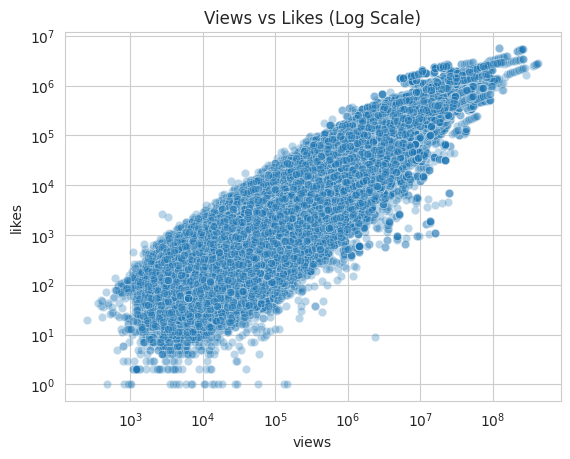

In [ ]:
plt.figure()
sns.scatterplot(data=df, x='views', y='likes', alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.title("Views vs Likes (Log Scale)")
plt.show()

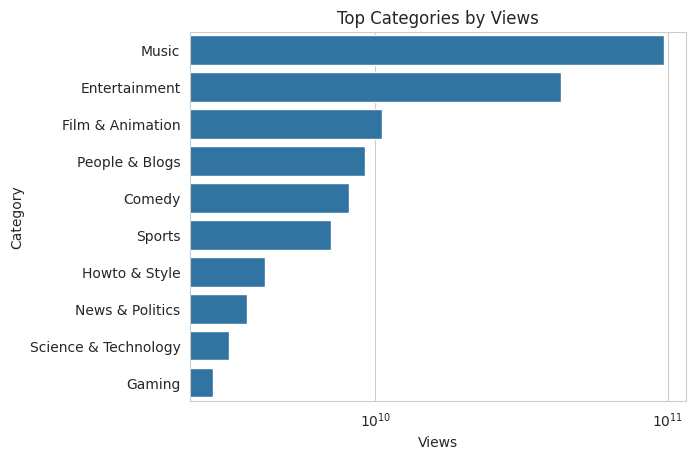

In [ ]:
# map category names
import json

with open("/content/youtube_dataset/IN_category_id.json") as f:
    data = json.load(f)

category_map = {int(i['id']): i['snippet']['title'] for i in data['items']}

df['category_name'] = df['category_id'].map(category_map)

# plot
top_categories = df.groupby('category_name')['views'].sum().sort_values(ascending=False).head(10)

plt.figure()
sns.barplot(x=top_categories.values, y=top_categories.index)
plt.xscale('log')
plt.title("Top Categories by Views")
plt.xlabel("Views")
plt.ylabel("Category")
plt.show()

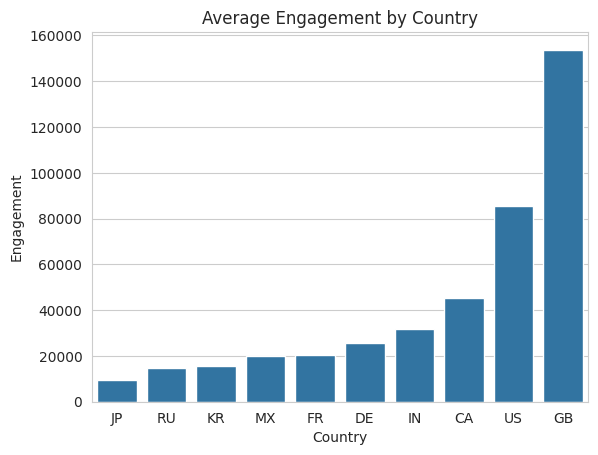

In [ ]:
country_engagement = df.groupby('country')['engagement'].mean().sort_values()

plt.figure()
sns.barplot(x=country_engagement.index, y=country_engagement.values)
plt.title("Average Engagement by Country")
plt.xlabel("Country")
plt.ylabel("Engagement")
plt.show()

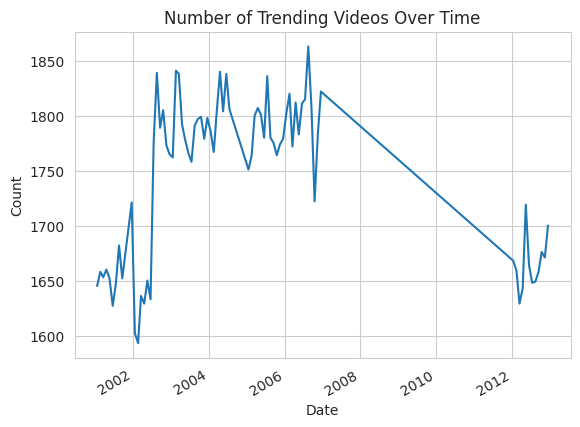

In [ ]:
df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m')
trend = df.groupby('trending_date').size()

plt.figure()
trend.plot()
plt.title("Number of Trending Videos Over Time")
plt.xlabel("Date")
plt.ylabel("Count")
plt.show()

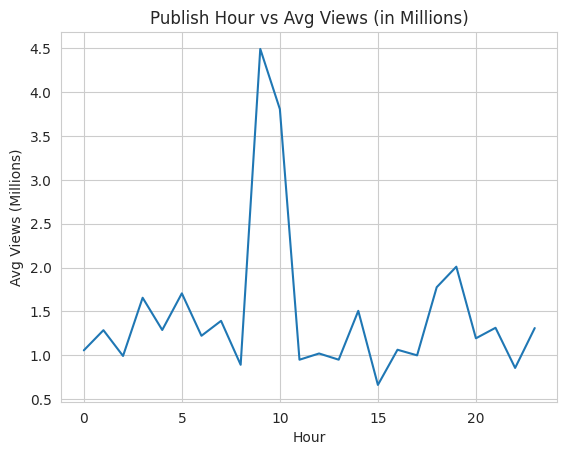

In [ ]:
df['publish_time'] = pd.to_datetime(df['publish_time'], utc=True)

df['publish_time_ist'] = df['publish_time'].dt.tz_convert('Asia/Kolkata')

df['publish_hour'] = df['publish_time_ist'].dt.hour
hour_views = df.groupby('publish_hour')['views'].mean() / 1e6

plt.figure()
sns.lineplot(x=hour_views.index, y=hour_views.values)
plt.title("Publish Hour vs Avg Views (in Millions)")
plt.xlabel("Hour")
plt.ylabel("Avg Views (Millions)")
plt.show()

most profitable time to publish a video in IST

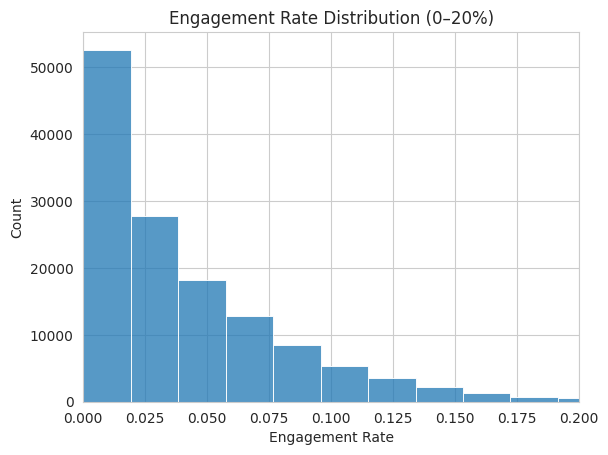

In [ ]:
plt.figure()
sns.histplot(df['engagement_rate'], bins=50)
plt.xlim(0, 0.2)   # 🔥 zoom
plt.title("Engagement Rate Distribution (0–20%)")
plt.xlabel("Engagement Rate")
plt.ylabel("Count")
plt.show()

In [ ]:
import json

with open("/content/youtube_dataset/IN_category_id.json") as f:
    data = json.load(f)

category_map = {
    int(item['id']): item['snippet']['title']
    for item in data['items']
}

In [ ]:
df['category_name'] = df['category_id'].map(category_map)

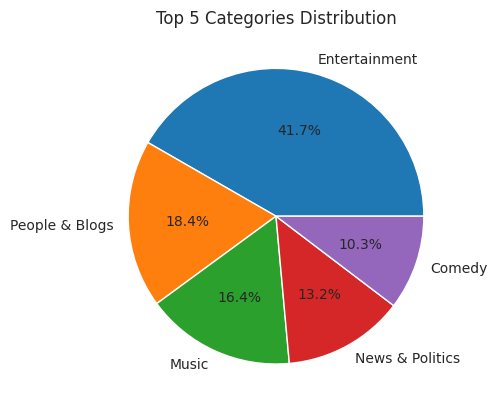

In [ ]:
category_counts = df['category_name'].value_counts().head(5)

plt.figure()
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%')
plt.title("Top 5 Categories Distribution")
plt.show()

In [ ]:
india_df = df[df['country'] == 'IN']

In [ ]:

india_df = df[df['country'] == 'IN'].copy()
india_df['engagement'] = india_df['likes'] + india_df['comment_count']

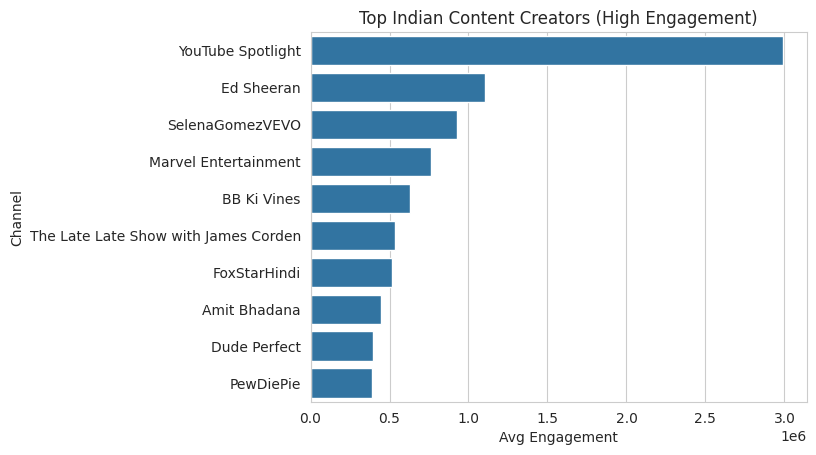

In [ ]:
top_creators = (
    india_df.groupby('channel_title')['engagement']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
sns.barplot(x=top_creators.values, y=top_creators.index)
plt.title("Top Indian Content Creators (High Engagement)")
plt.xlabel("Avg Engagement")
plt.ylabel("Channel")
plt.show()

3. Top creators overall (best for ads)

In [ ]:
import json

with open("/content/youtube_dataset/IN_category_id.json") as f:
    data = json.load(f)

category_map = {int(i['id']): i['snippet']['title'] for i in data['items']}

india_df['category_name'] = india_df['category_id'].map(category_map)

In [ ]:
target_categories = {
    "Education": ["Education"],
    "Health": ["Howto & Style", "People & Blogs"],
    "Fashion & Beauty": ["Howto & Style"]
}

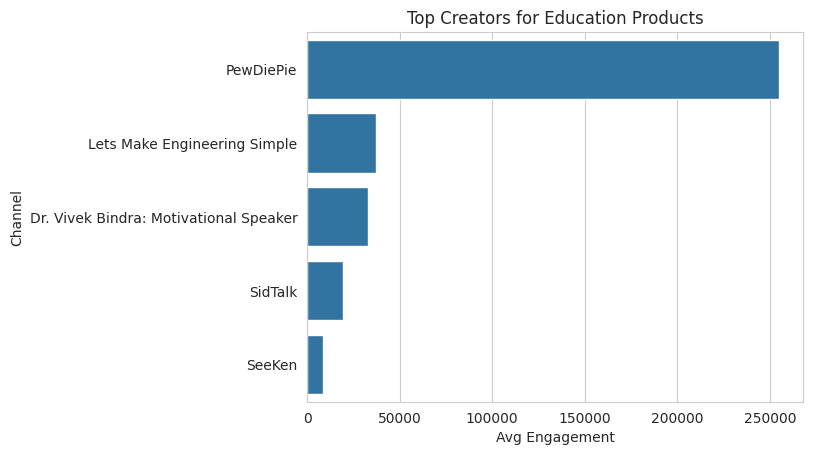

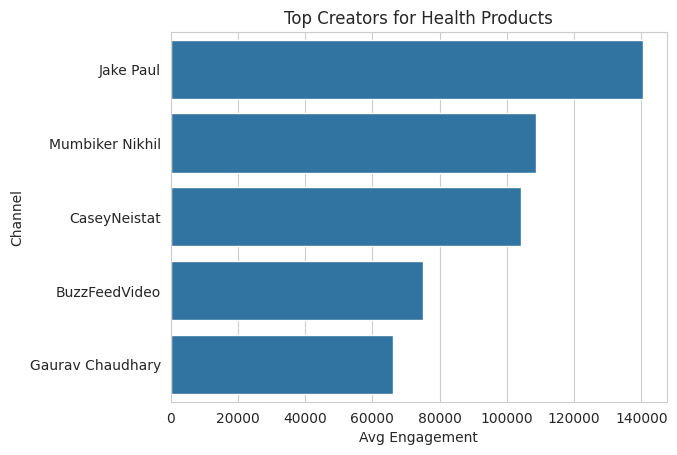

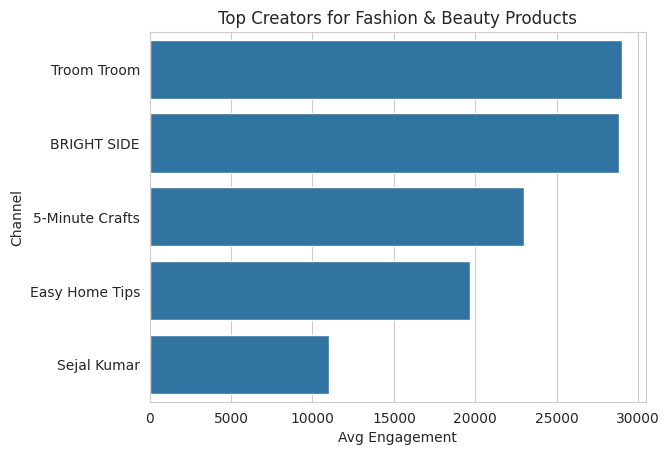

In [ ]:
def get_top_creators(category_list, title):
    temp = india_df[india_df['category_name'].isin(category_list)]

    top = (
        temp.groupby('channel_title')['engagement']
        .mean()
        .sort_values(ascending=False)
        .head(5)
    )

    plt.figure()
    sns.barplot(x=top.values, y=top.index)
    plt.title(f"Top Creators for {title}")
    plt.xlabel("Avg Engagement")
    plt.ylabel("Channel")
    plt.show()
get_top_creators(target_categories["Education"], "Education Products")

get_top_creators(target_categories["Health"], "Health Products")

get_top_creators(target_categories["Fashion & Beauty"], "Fashion & Beauty Products")

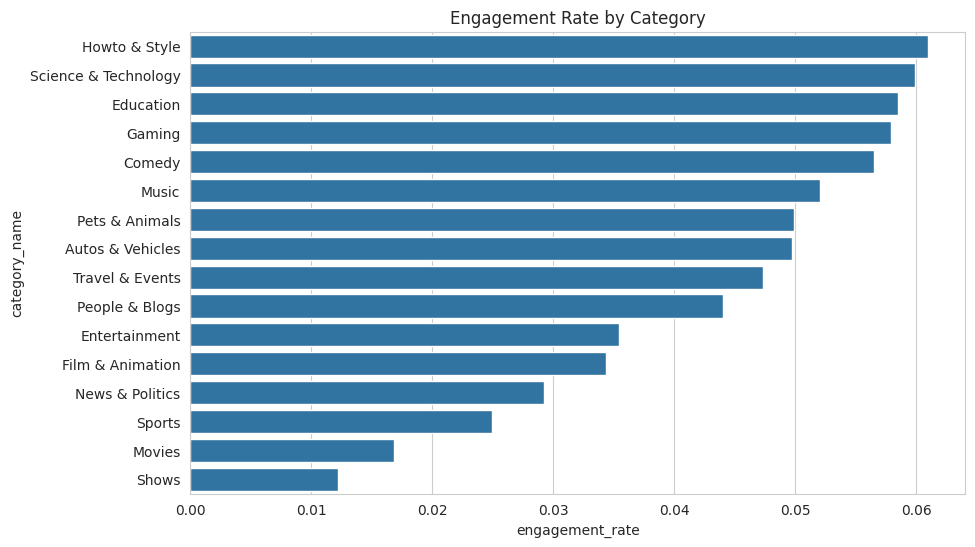

In [ ]:
category_engagement = (
    df.groupby('category_name')['engagement_rate']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(x='engagement_rate', y='category_name', data=category_engagement)
plt.title("Engagement Rate by Category")
plt.show()

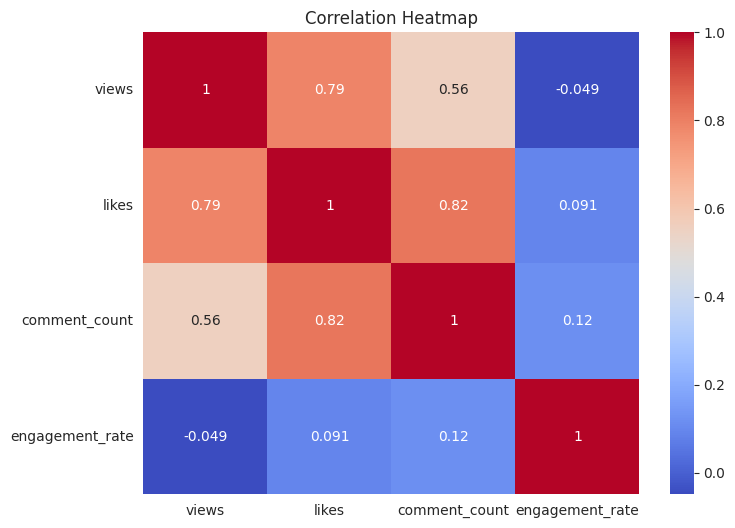

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['views','likes','comment_count','engagement_rate']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df['publish_time'] = pd.to_datetime(df['publish_time'], utc=True)
df['publish_time'] = df['publish_time'].dt.tz_convert('Asia/Kolkata')

df['day'] = df['publish_time'].dt.day_name()

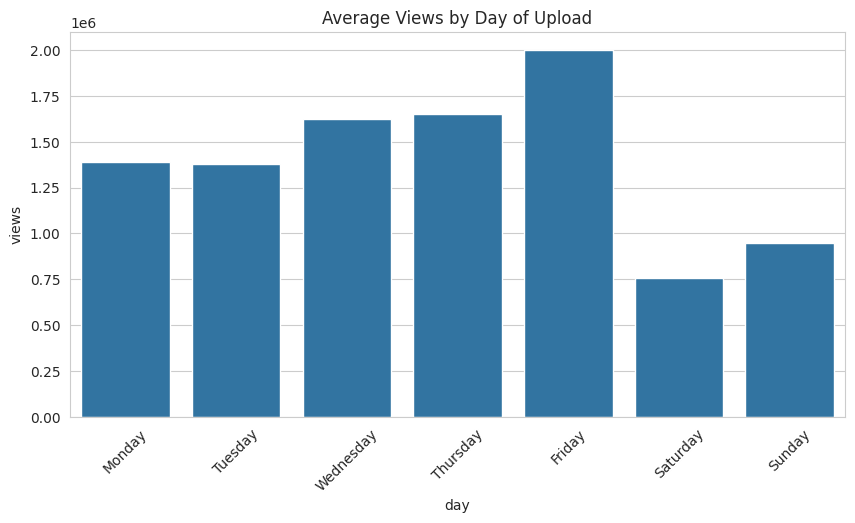

In [ ]:
day_views = df.groupby('day')['views'].mean().reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
]).reset_index()

plt.figure(figsize=(10,5))
sns.barplot(x='day', y='views', data=day_views)
plt.title("Average Views by Day of Upload")
plt.xticks(rotation=45)
plt.show()